In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version


In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"Tephra layer"
measure = "mm" if "d18o" in data["dn"] else "cm"


In [3]:
base_dir = Path.cwd()
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

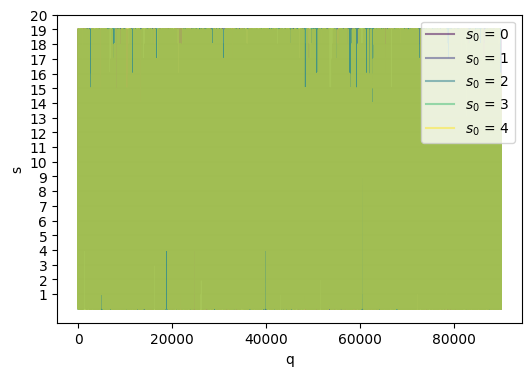

In [5]:
import matplotlib as mpl
cutout = 10000
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode = "r")[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
# plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, :])
print(num_samples)
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(90000* round_trip / (num_samples * num_temps))


90001
267.39702892190087


In [7]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [8]:
import arviz as az
# print(az.summary(samples))
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[19520.10649497 23209.64816227 22091.5548227  23747.46182602
 20612.69023422 20821.15942849 21318.22019949 24310.5134833
 20930.59671124 21056.29178656 22484.24238537 28571.7337292
 34766.77609926 28496.41267667 29303.0931758  41363.00169693
 42565.89328521 42328.31160542 34321.35970667 34609.55048191
 36665.40247206 24754.454487   20894.41175342 26397.40318181
 24247.01158589 22786.30423227 22749.17450275 24400.37253533
 25467.78669482 25314.71748979 24916.43861194 21871.99196249
 20714.94798336 20570.11504927 18878.9426623  18866.97300862
 13671.25097223 22714.16271442 23276.10043336 21167.8771162
 25507.83701181 30886.18635569 31115.17360149 24428.18050786
 27388.89409419 25279.83089061 27558.88875371 28700.02982169
 29210.49472243 25568.03932129]
13671.250972234038


In [9]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(66.85330890993947), np.float64(69.39898849648658), np.float64(70.60264998438196), np.float64(71.07564579173086), np.float64(73.36217616505705), np.float64(74.7447694130147), np.float64(75.74955301481606), np.float64(78.4810829366983), np.float64(80.92956682674273), np.float64(83.3213054779121), np.float64(85.88347136899559), np.float64(90.37824986208408), np.float64(93.45771643389557), np.float64(98.48439859871283), np.float64(104.80220269219446), np.float64(110.39743523069183), np.float64(117.75805387436995), np.float64(126.74283696483528), np.float64(136.38105982036592), np.float64(148.41235331512763)]


In [10]:
# for i in range(0, pt_config["nt"] - 1):
#     temp_indices_i = (temp_indices == i).argmax(axis=0)
#     print(np.min(temp_indices_i))
#     rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
#     print(rej_indices)
#     rej = 0
#     for j in range(len(rej_indices)):
#         rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
#     print(rej / pt_config["hmcc"]["ns"])

In [11]:
index = 38
interesting_depth = index * data["dc"]

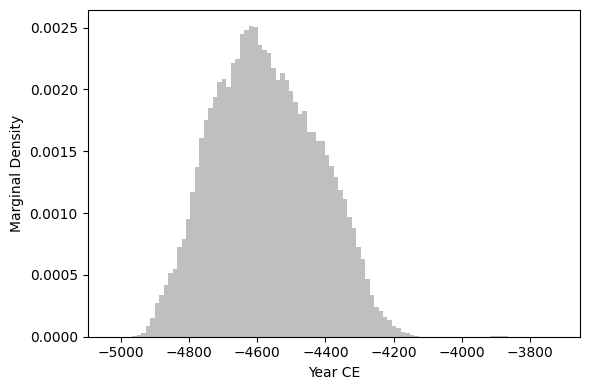

In [12]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
plt.tight_layout()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

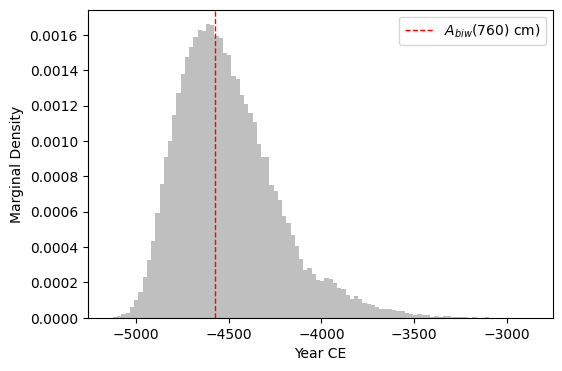

In [13]:
index2 = 38
CV_values = data["th"] - data["dc"] * np.sum(samples[0, :, :index2], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index2], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(index2 *data["dc"])}) " + measure + ")")
plt.legend()
# plt.savefig(f"{output_dir}/highT_samples_along_depth_{int(index2 *data["dc"])}.jpg")
plt.show()

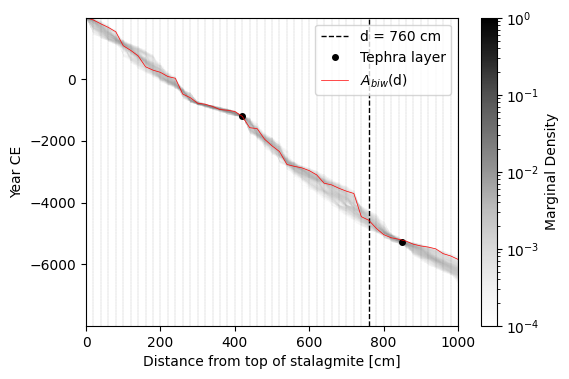

11757

In [14]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1),
    interpolation = "nearest",
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


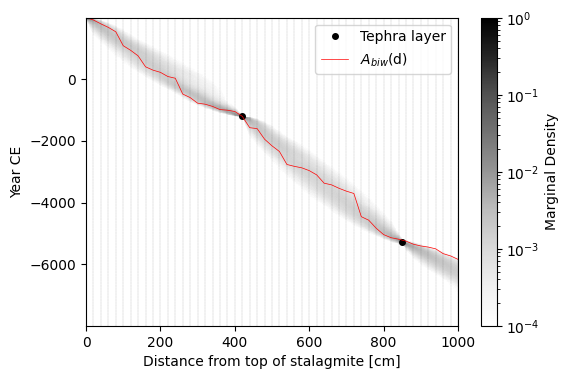

16550

In [16]:
from matplotlib import colors

X = samples[0, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1),
    interpolation = "nearest"
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
